In [12]:
from tensorflow.keras.datasets import cifar10
import cv2, os

(x_train, _), (_, _) = cifar10.load_data()

os.makedirs("dataset", exist_ok=True)

for i in range(20):
    img = cv2.cvtColor(x_train[i], cv2.COLOR_RGB2BGR)
    cv2.imwrite(f"dataset/img_{i}.jpg", img)

cv2.imwrite("query.jpg", cv2.cvtColor(x_train[25], cv2.COLOR_RGB2BGR))

print("Dataset images and query image created successfully")


Dataset images and query image created successfully


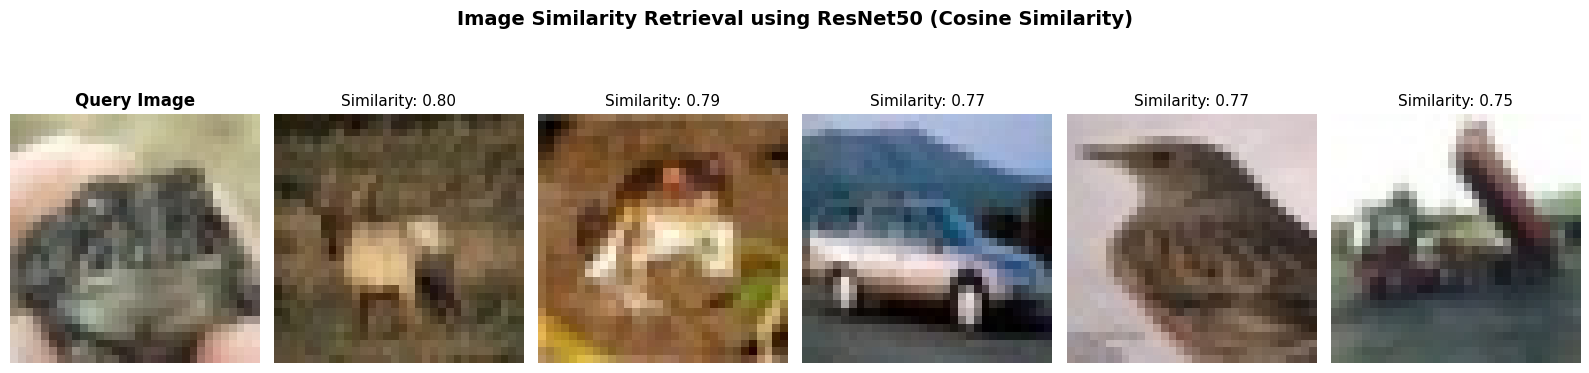

Final output generated and saved as final_output.png


In [14]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # hide TensorFlow warnings

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.metrics.pairwise import cosine_similarity

# Load pretrained ResNet50 model
model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return model.predict(x, verbose=0).flatten()

# Load dataset images
image_paths = sorted([f"dataset/{img}" for img in os.listdir("dataset")])
features = np.array([extract_features(p) for p in image_paths])

# Extract query image features
query_feature = extract_features("query.jpg")

# Compute cosine similarity
scores = cosine_similarity([query_feature], features)[0]
top_idx = scores.argsort()[-5:][::-1]

# ---------- CLEAN & FINAL VISUAL OUTPUT ----------
plt.figure(figsize=(16,4))

# Query image
plt.subplot(1,6,1)
plt.imshow(image.load_img("query.jpg"))
plt.title("Query Image", fontsize=12, fontweight='bold')
plt.axis("off")

# Retrieved similar images
for i, idx in enumerate(top_idx):
    plt.subplot(1,6,i+2)
    plt.imshow(image.load_img(image_paths[idx]))
    plt.title(f"Similarity: {scores[idx]:.2f}", fontsize=11)
    plt.axis("off")

plt.suptitle(
    "Image Similarity Retrieval using ResNet50 (Cosine Similarity)",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("final_output.png", dpi=300, bbox_inches='tight')
plt.show()

print("Final output generated and saved as final_output.png")
